In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/pune_property_clean.csv")
sns.set_theme(style="whitegrid")
print(df.shape)

(28432, 51)


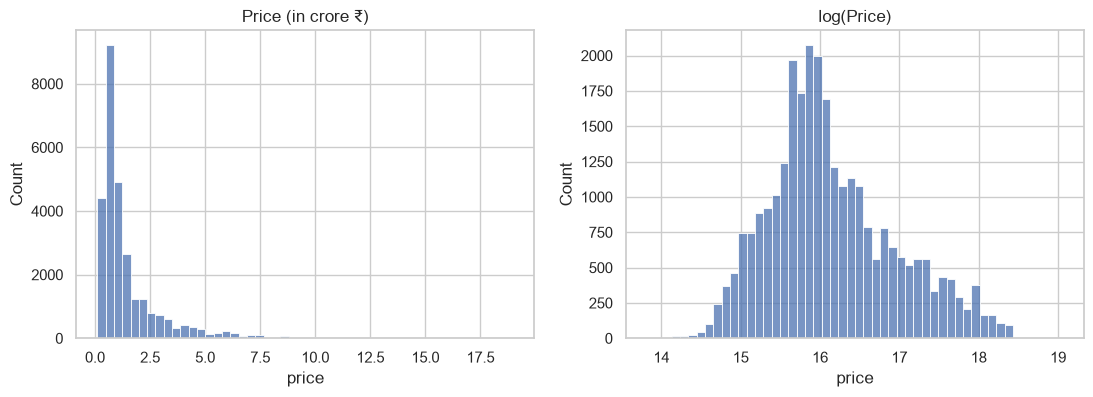

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["price"] / 1e7, bins=50, ax=ax[0])
ax[0].set_title("Price (in crore ₹)")
sns.histplot(np.log(df["price"]), bins=50, ax=ax[1])
ax[1].set_title("log(Price)")
plt.show()

In [4]:
df["price_per_sqft"] = df["price"] / df["area"]
df["price_per_sqft"].describe()

count    28432.000000
mean      7876.137266
std       3183.071107
min       3350.000000
25%       5701.754386
50%       6967.870968
75%       9152.542373
max      19065.776930
Name: price_per_sqft, dtype: float64

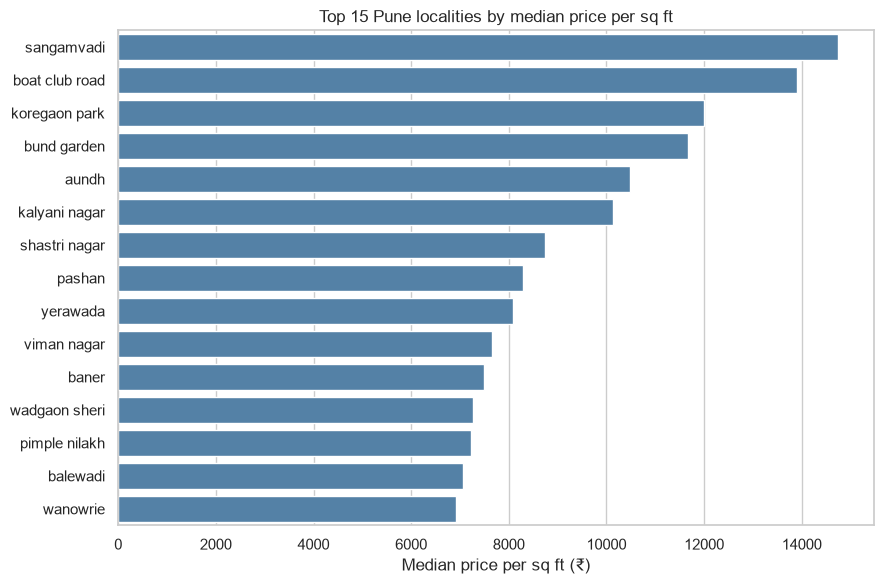

In [5]:
stats = (df.groupby("locality")
           .agg(listings=("price", "size"),
                median_psf=("price_per_sqft", "median"))
           .query("listings >= 100")
           .sort_values("median_psf", ascending=False))

top = stats.head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=top["median_psf"], y=top.index, color="steelblue")
plt.title("Top 15 Pune localities by median price per sq ft")
plt.xlabel("Median price per sq ft (₹)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../reports/figures/top_localities_psf.png", dpi=150)
plt.show()

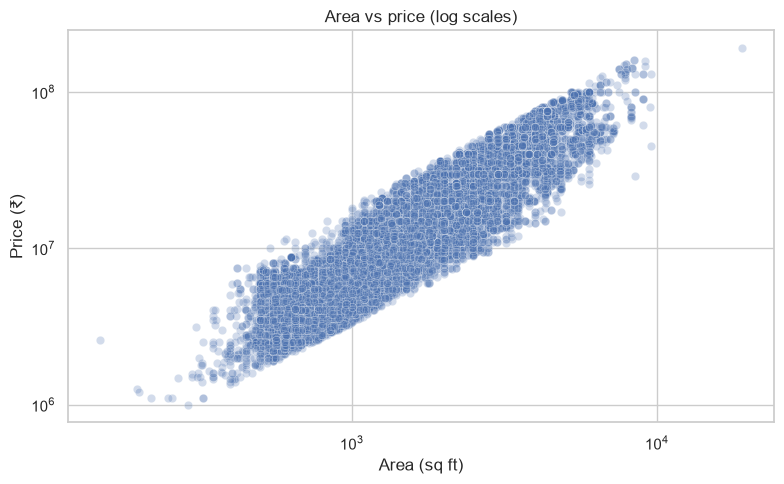

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="area", y="price", alpha=0.25)
plt.xscale("log"); plt.yscale("log")
plt.title("Area vs price (log scales)")
plt.xlabel("Area (sq ft)"); plt.ylabel("Price (₹)")
plt.tight_layout()
plt.savefig("../reports/figures/area_vs_price.png", dpi=150)
plt.show()

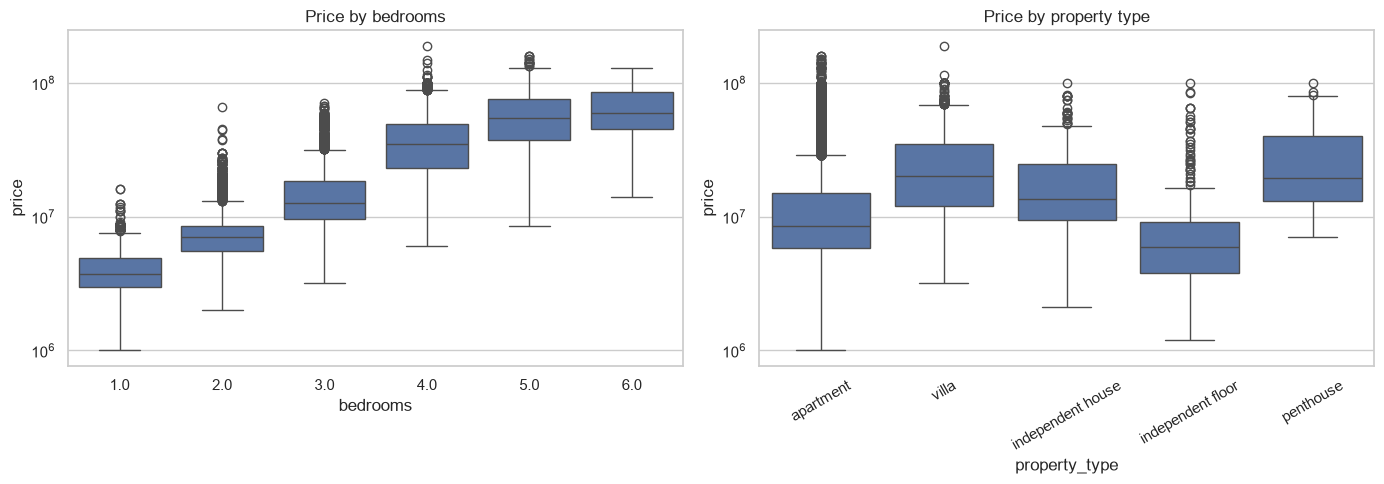

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df[df["bedrooms"] <= 6], x="bedrooms", y="price", ax=ax[0])
ax[0].set_yscale("log"); ax[0].set_title("Price by bedrooms")
sns.boxplot(data=df, x="property_type", y="price", ax=ax[1])
ax[1].set_yscale("log"); ax[1].set_title("Price by property type")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../reports/figures/bedrooms_type_vs_price.png", dpi=150)
plt.show()

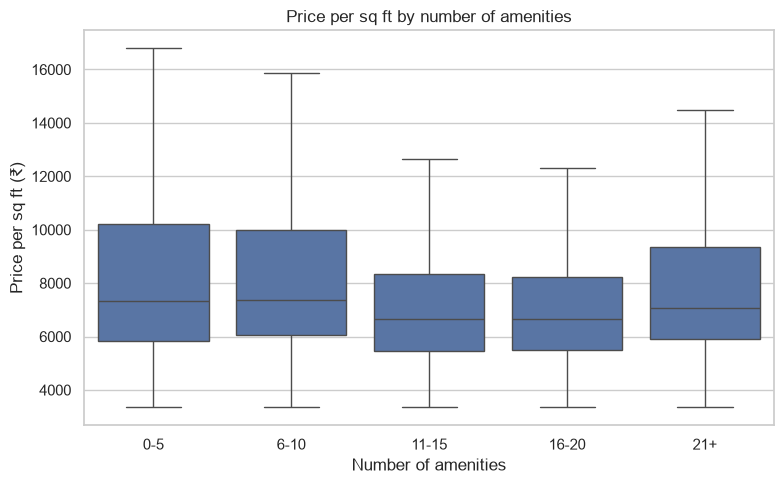

In [8]:
df["amenity_group"] = pd.cut(df["amenity_count"], bins=[-1, 5, 10, 15, 20, 35],
                             labels=["0-5", "6-10", "11-15", "16-20", "21+"])
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="amenity_group", y="price_per_sqft", showfliers=False)
plt.title("Price per sq ft by number of amenities")
plt.xlabel("Number of amenities"); plt.ylabel("Price per sq ft (₹)")
plt.tight_layout()
plt.savefig("../reports/figures/amenities_vs_psf.png", dpi=150)
plt.show()

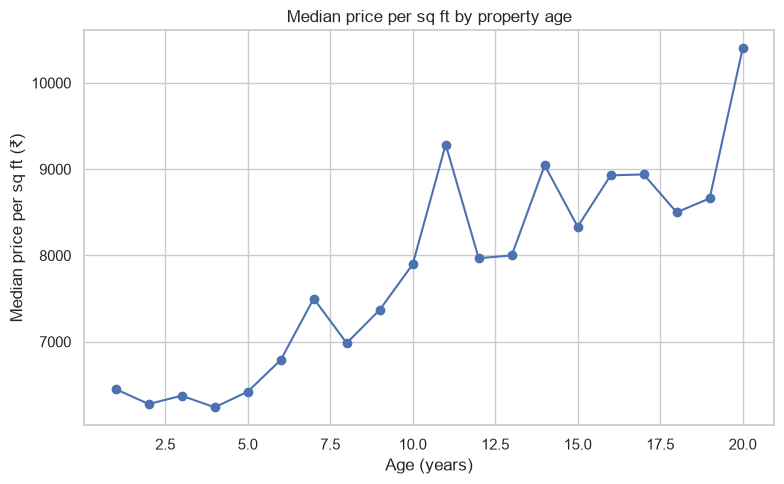

In [9]:
age_psf = df[df["age"] <= 20].groupby("age")["price_per_sqft"].median()
plt.figure(figsize=(8, 5))
plt.plot(age_psf.index, age_psf.values, marker="o")
plt.title("Median price per sq ft by property age")
plt.xlabel("Age (years)"); plt.ylabel("Median price per sq ft (₹)")
plt.tight_layout()
plt.savefig("../reports/figures/age_vs_psf.png", dpi=150)
plt.show()

In [10]:
num = df.select_dtypes("number").drop(columns=["price", "price_per_sqft"])
corr = num.corrwith(np.log(df["price"])).sort_values(ascending=False)
print(corr.head(8))
print(corr.tail(5))

area          0.865239
bedrooms      0.842902
bathroom      0.826195
balconies     0.463099
opensides     0.366350
addi_rooms    0.302108
am_sofa       0.195741
am_bed        0.185267
dtype: float64
am_jogging_track           -0.091811
am_children_s_play_area    -0.104106
am_landscaped_gardens      -0.106324
am_rain_water_harvesting   -0.116831
am_indoor_games            -0.131547
dtype: float64


In [11]:
print(df[(df["area"] < 250) | (df["area"] > 10000)]
        [["locality", "property_type", "bedrooms", "area", "price"]])

              locality      property_type  bedrooms     area      price
877    magarpatta road          apartment       1.0    150.0    2600000
16126    koregaon park              villa       4.0  19000.0  190000000
20305        bebadohal          apartment       1.0    220.0    1100000
20406            narhe          apartment       1.0    198.0    1250000
20789         lonikand  independent floor       1.0    200.0    1200000
